In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *
import matplotlib.pyplot as plt

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

x += torch.randn_like(x) * dx * 0.1

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [5]:
nSamples = 8

In [6]:
from tqdm.autonotebook import tqdm

def benchmarkDensity(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses, 
        densities_warp, densities_diffSPH, 
        queryQuantity, referenceQuantity,
        domain, adjacency, neighborhood, simulationState,
        nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False
):
    measurements = []
    for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, gpuTime, cpuTime = timeFunction(
            sphOperation_warp,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            densities_warp, densities_warp,
            queryQuantity, referenceQuantity,
            domain, adjacency,
            operation=WarpOperation.Density,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'Density',
            'backend': 'warp',
            'gpuTime': gpuTime,
            'cpuTime': cpuTime
        })
    if warpOnly == True:
        return measurements
    for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
                simulationState,
                quantity = referenceQuantity,
                kernel = KernelType.Wendland2,
                neighborhood = neighborhood[0],
                kernelValues = neighborhood[1],
                operation=Operation.Density,
                supportScheme = SupportScheme.Gather,
                correctionTerms= [],
                positiveDivergence=False
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'Density',
            'backend': 'diffSPH',
            'gpuTime': diffsph_gpu_time,
            'cpuTime': diffsph_cpu_time
        })

    # for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
    #     diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
    #             simulationState,
    #             quantity = referenceQuantity,
    #             kernel = KernelType.Wendland2,
    #             neighborhood = neighborhood[0],
    #             kernelValues = None,
    #             operation=Operation.Density,
    #             supportScheme = SupportScheme.Gather,
    #             correctionTerms= [],
    #             positiveDivergence=False
    #     )
    #     measurements.append({
    #         'numParticles': nx**dim,
    #         'targetNumNeighbors': targetNumNeighbors,
    #         'dim': dim,
    #         'device': device,
    #         'operation': 'Density',
    #         'backend': 'diffSPH [no pre]',
    #         'gpuTime': diffsph_gpu_time,
    #         'cpuTime': diffsph_cpu_time
    #     })
    return measurements

def benchmarkOperation(
        operation, gradientMode, laplacianMode,
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses, 
        densities_warp, densities_diffSPH, 
        queryQuantity, referenceQuantity,
        domain, adjacency, neighborhood, simulationState,
        nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False
):
    measurements = []
    for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, gpuTime, cpuTime = timeFunction(
            sphOperation_warp,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            densities_warp, densities_warp,
            queryQuantity, referenceQuantity,
            domain, adjacency,
            operation=operation, gradientMode=gradientMode, laplacianMode=laplacianMode,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': operation.name,
            'backend': 'warp',
            'gpuTime': gpuTime,
            'cpuTime': cpuTime
        })
    if warpOnly == True:
        return measurements
    diffSPHOperation, diffSPHGradientMode, diffSPHLaplacianMode = warptodiffOperation(operation, gradientMode, laplacianMode)
    for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
                simulationState,
                quantity = referenceQuantity,
                kernel = KernelType.Wendland2,
                neighborhood = neighborhood[0],
                kernelValues = neighborhood[1],
                operation=diffSPHOperation,
                gradientMode=diffSPHGradientMode,
                laplacianMode=diffSPHLaplacianMode,
                supportScheme = SupportScheme.Gather,
                correctionTerms= [],
                positiveDivergence=False
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': diffSPHOperation.name,
            'backend': 'diffSPH',
            'gpuTime': diffsph_gpu_time,
            'cpuTime': diffsph_cpu_time
        })
        
    # diffSPHOperation, diffSPHGradientMode, diffSPHLaplacianMode = warptodiffOperation(operation, gradientMode, laplacianMode)
    # for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
    #     diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
    #             simulationState,
    #             quantity = referenceQuantity,
    #             kernel = KernelType.Wendland2,
    #             neighborhood = neighborhood[0],
    #             kernelValues = None,
    #             operation=diffSPHOperation,
    #             gradientMode=diffSPHGradientMode,
    #             laplacianMode=diffSPHLaplacianMode,
    #             supportScheme = SupportScheme.Gather,
    #             correctionTerms= [],
    #             positiveDivergence=False
    #     )
    #     measurements.append({
    #         'numParticles': nx**dim,
    #         'targetNumNeighbors': targetNumNeighbors,
    #         'dim': dim,
    #         'device': device,
    #         'operation': diffSPHOperation.name,
    #         'backend': 'diffSPH [no pre]',
    #         'gpuTime': diffsph_gpu_time,
    #         'cpuTime': diffsph_cpu_time
    #     })
    return measurements

/tmp/ipykernel_507949/828811123.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [7]:
from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme

def computeCRKFactorsDiffSPH(simulationState, neighborhood, adjacency):
    simulationState.omega = torch.ones_like(simulationState.masses)
    simulationState.apparentArea = computeCRKVolume(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.Gather, {})
    kernelMoments = computeGeometricMoments(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.SuperSymmetric, {})       
    simulationState.numNeighbors = adjacency.numNeighbors
    simulationState.A, simulationState.B, simulationState.gradA, simulationState.gradB = computeCRKTerms(kernelMoments, simulationState.numNeighbors, simulationState.supports)
    # simulationState.A, simulationState.B = None, None
    densities = computeCRKDensity(simulationState, KernelType.Wendland2, neighborhood, SupportScheme.SuperSymmetric, {})
    # f = 2 + queryPositions[:,0] * 20
    return simulationState.apparentArea, densities, simulationState.A, simulationState.B, simulationState.gradA, simulationState.gradB

from sphWarpCore.crk import *

def benchmarkCRK(
        operation, gradientMode, laplacianMode,
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses, 
        densities_warp, densities_diffSPH, 
        queryQuantity, referenceQuantity,
        domain, adjacency, neighborhood, simulationState,
        nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False
):
    measurements = []
    for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, gpuTime, cpuTime = timeFunction(computeCRKFactors, 
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            domain = domain, adjacency = adjacency, 
            operationMode = OperationDirection.AllToAll,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'CRK Factor Computation',
            'backend': 'warp',
            'gpuTime': gpuTime,
            'cpuTime': cpuTime
        })
    if warpOnly == True:
        return measurements
    
    for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, diffsph_gpu_time, diffsph_cpu_time = timeFunction(computeCRKFactorsDiffSPH, simulationState, neighborhood, adjacency)
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'CRK Factor Computation',
            'backend': 'diffSPH',
            'gpuTime': diffsph_gpu_time,
            'cpuTime': diffsph_cpu_time
        })
    return measurements



In [8]:

def benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False):
        with record_function(f"Total benchmark for {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}"):
            with record_function("Data Preparation"):
                queryPositions, referencePositions, \
                        querySupports, referenceSupports, \
                        queryMasses, referenceMasses, \
                        queryDensities, referenceDensities, \
                        domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, warpOnly)
            with record_function("Density Computation"):
                densityResults = benchmarkDensity(
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    None, None,
                    domain, adjacency, neighborhood, simulationState,
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(densityResults)


            f = torch.randn((queryPositions.shape[0],), device = queryPositions.device, dtype = queryPositions.dtype)
            with record_function("Interpolation Operations"):
                interpolationResults = benchmarkOperation(
                    WarpOperation.Interpolate, GradientScheme.Naive, LaplacianScheme.Naive,
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    f, f,
                    domain, adjacency, neighborhood, simulationState,       
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(interpolationResults)
            with record_function("Gradient Operations"):
                gradientResults = benchmarkOperation(
                    WarpOperation.Gradient, GradientScheme.Difference, LaplacianScheme.Naive,
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    f, f,
                    domain, adjacency, neighborhood, simulationState,
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(gradientResults)
            with record_function("Laplacian Operations"):
                LaplacianResults = benchmarkOperation(
                    WarpOperation.Laplacian, GradientScheme.Difference, LaplacianScheme.Brookshaw,
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    f, f,
                    domain, adjacency, neighborhood, simulationState,
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(LaplacianResults)

            f_vector = torch.randn((queryPositions.shape[0], queryPositions.shape[1]), device = queryPositions.device, dtype = queryPositions.dtype)
            with record_function("Divergence Operations"):
                divergenceResults = benchmarkOperation(
                    WarpOperation.Divergence, GradientScheme.Difference, LaplacianScheme.Brookshaw,
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    f_vector, f_vector,
                    domain, adjacency, neighborhood, simulationState,
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(divergenceResults)

            with record_function("CRK Factor Computation"):
                crkResults = benchmarkCRK(
                    WarpOperation.Density, GradientScheme.Difference, LaplacianScheme.Brookshaw,
                    queryPositions, referencePositions,
                    querySupports, referenceSupports,
                    queryMasses, referenceMasses,
                    queryDensities, referenceDensities,
                    None, None,
                    domain, adjacency, neighborhood, simulationState,
                    nx, targetNumNeighbors, dim, device, nSamples, warpOnly
                )
                measurements.extend(crkResults)
            

            return measurements

In [9]:
from demo_util import *

In [10]:
nxs = [16, 32, 64, 128, 256, 512, 1024]

numParticles = np.logspace(10, 16, num=32, dtype=int, base = 2)
print(numParticles)
nxs = [int(np.sqrt(num)) for num in numParticles]

targetNumNeighbors = 50
dims = [2]
devices = ['cuda'] if torch.cuda.is_available() else ['cpu']
# devices = ['cpu']
all_measurements = []
nSamples = 16

warpOnly = False

_ = benchmark(nxs[0], targetNumNeighbors, dims[0], devices[0], nSamples , warpOnly)


[ 1024  1171  1339  1531  1751  2002  2290  2619  2995  3425  3916  4479
  5122  5857  6698  7660  8760 10018 11456 13101 14982 17133 19593 22406
 25623 29301 33508 38319 43821 50113 57308 65536]
Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

        dist_sq += dx * dx

                    edge_index += 1

                    edge_index += 1

            continue  # No particles in this cell

                    count += 1

                    count += 1

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap 

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

Benchmarking [diffSPH] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i4_a1i4_b_i4_a1i4_a1i4_b_a1f4_a1f4_b_a1f4_a1v2f4_a1f4
Module sphWarpCore.operations.wp_interpolate 6fb293e load on device 'cuda:0' (block_dim=256) ...
        out += fv * vj * w_ij

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.crk.crk_volume_c42e4ac.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.

...

[Kernel.add_overload] Creating new overload for computeSPHDivergenceTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v2f4_a1v2f4_a1f4_a1f4_a1b_u4_i4_i4_b_a1i8_a1i4_a1i4_b_i4_i4_i4_b_i4_a1i4_a1i4_b_a1m22f4_b_a1f4_a1f4_b_a1f4_a1f4_b_a1f4_a1v2f4_a1v2f4_a1m22f4_a1v1f4
Module sphWarpCore.operations.wp_divergence 231ddf1 load on device 'cuda:0' (block_dim=256) ...
                res[i] += fij[i + d * outputElements] * kernelGradient[d]

            out += divergenceProduct((fj + fi) * apparentVolume, kernelGradient, outputValue, flatOutputShape, dotMode)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.crk.crk_volume_c42e4ac.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documen

Benchmarking [diffSPH] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

[Kernel.add_overload] Creating new overload for computeCRKVolume_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i4_a1i4_b_i4_a1i4_a1i4_b_a1m22f4_b_a1f4_a1f4_b_a1f4_a1f4_b_a1f4_a1v2f4_a1v2f4_a1m22f4_a1f4
Module sphWarpCore.crk.crk_volume 964ce1d load on device 'cuda:0' (block_dim=256) ...
        out += w_ij

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.crk.crk_volume_c42e4ac.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.p

Benchmarking [diffSPH] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

In [11]:

from torch.profiler import profile, record_function, ProfilerActivity

_ = benchmark(256, targetNumNeighbors, dims[0], devices[0], 8, False)

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    _ = benchmark(256, targetNumNeighbors, dims[0], devices[0], 1, False)


    
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))

prof.export_chrome_trace("profile.json")

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/8 [00…

Benchmarking [diffSPH] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/8 …

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/8 [00…

Benchmarking [diffSPH] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/8 …

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/8 [00…

...

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/1 [00…

Benchmarking [diffSPH] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/1 …

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/1 [00…

Benchmarking [diffSPH] with 65536 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/1 …

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
Total benchmark for 65536 particles, target neighbor...         0.15%     755.357us        99.73%     504.630ms     504.630ms       0.000us         0.00%     202.772ms     202.772ms             1  
                                       Data Preparation         0.40%       2.045ms        49.93%     252.626ms     252.626ms       0.000us         0.00%      39.405ms      39.405ms             1  
         

In [ ]:
nxs = [16, 32, 64, 128, 256]

numParticles = np.logspace(10, 16, num=32, dtype=int, base = 2)
print(numParticles)
nxs = [int(np.sqrt(num)) for num in numParticles]

targetNumNeighbors = 50
dims = [2]
devices = ['cuda'] if torch.cuda.is_available() else ['cpu']
# devices = ['cpu']
all_measurements = []
nSamples = 16

warpOnly = False

_ = benchmark(nxs[0], targetNumNeighbors, dims[0], devices[0], nSamples , warpOnly)

for device in tqdm(devices, desc = "Devices"):
    for dim in tqdm(dims, desc = "Dimensions", leave=False):
        for nx in tqdm(nxs, desc = "Resolutions", leave=False):
            measurements = benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly)
            all_measurements.extend(measurements)

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pdData = pd.DataFrame(all_measurements)
pdData = pdData[pdData['dim'] == 2]

display(pdData)

,numParticles,targetNumNeighbors,dim,device,operation,backend,gpuTime,cpuTime
0,1024,50,2,cuda,Adjacency,warp,9.202720,9.272099
1,1024,50,2,cuda,Adjacency,diffSPH,3.604928,3.643990
2,1024,50,2,cuda,State,diffSPH,9.897632,9.958982
3,1024,50,2,cuda,Density,warp,1.120224,1.284361
4,1024,50,2,cuda,Density,warp,0.415360,0.493526
...,...,...,...,...,...,...,...,...
6235,65536,50,2,cuda,CRK Factor Computation,diffSPH,103.556541,103.790760
6236,65536,50,2,cuda,CRK Factor Computation,diffSPH,105.007133,105.232716
6237,65536,50,2,cuda,CRK Factor Computation,diffSPH,105.360641,105.591536
6238,65536,50,2,cuda,CRK Factor Computation,diffSPH,103.354271,103.647470


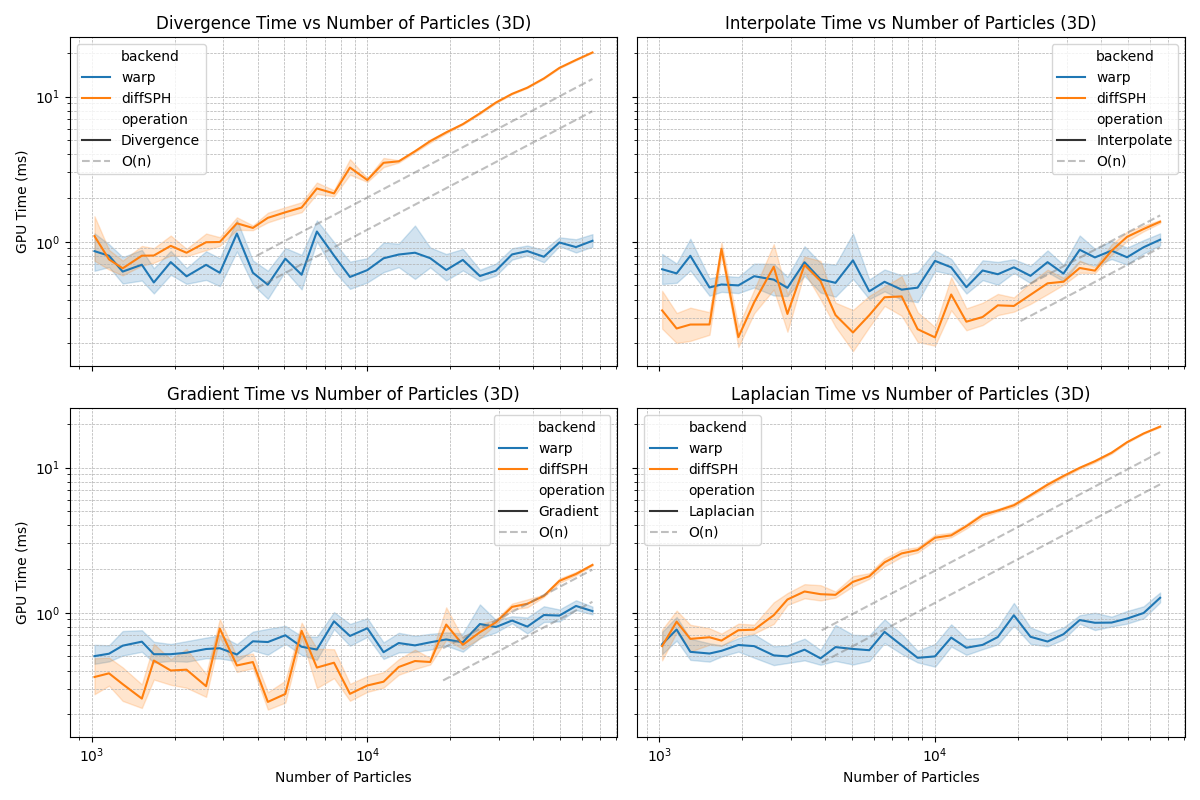

In [15]:
def add_scaling_line(ax, data, x_col, y_col, scale_factor=0.1, color='gray', linestyle='--', alpha=0.5):
    x_vals = data[x_col].unique()
    x_vals = np.sort(x_vals)
    y_mean = data.groupby(x_col)[y_col].mean()
    
    y_max = y_mean.max()
    y_min = y_mean.min()
    
    x_ref = x_vals[0]
    
    # print(f"x_vals: {x_vals}")
    # print(f"y_min: {y_min}, y_max: {y_max}")
    
    upper_scale = y_max * (1 + scale_factor)
    lower_scale = y_min * (1 + scale_factor)
    
    # now we want the line to go from [x, lower_scale] to [xmax, upper_scale] with a slope of 1 in log-log space, which means it should be a line of the form y = C * x, where C is a constant that we can determine based on the reference point (x_ref, y_ref)
    # print(f"upper_scale: {upper_scale}, lower_scale: {lower_scale}")
    y_ratio = upper_scale / lower_scale
    # print(f"y_ratio: {y_ratio}")
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    # print(f"x_lower: {x_lower}")
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha, label='O(n)')
    
    upper_scale = y_max * (1 - scale_factor)
    lower_scale = y_min * (1 - scale_factor)
    y_ratio = upper_scale / lower_scale
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha)
    
scale_factor = 0.25    

fig, axis = plt.subplots(2, 2, figsize = (12,8), squeeze = False, sharey = True, sharex=True)
import copy

plotData = copy.deepcopy(pdData)

def plotOp(data, operation, ax):
    curData =  data[data['operation'] == operation]

    sns.lineplot(data = curData, x = 'numParticles', y = 'gpuTime', style = 'operation', hue = 'backend', ax = ax, marker = None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Particles')
    ax.set_ylabel('GPU Time (ms)')
    ax.set_title(f'{operation} Time vs Number of Particles (3D)')
    ax.grid(True, which = 'both', linestyle='--', linewidth=0.5)
    add_scaling_line(ax, curData, 'numParticles', 'gpuTime', scale_factor=scale_factor)
    ax.legend()

plotOp(plotData, 'Divergence', axis[0, 0])
plotOp(plotData, 'Interpolate', axis[0, 1])
plotOp(plotData, 'Gradient', axis[1, 0])
plotOp(plotData, 'Laplacian', axis[1, 1])

fig.tight_layout()


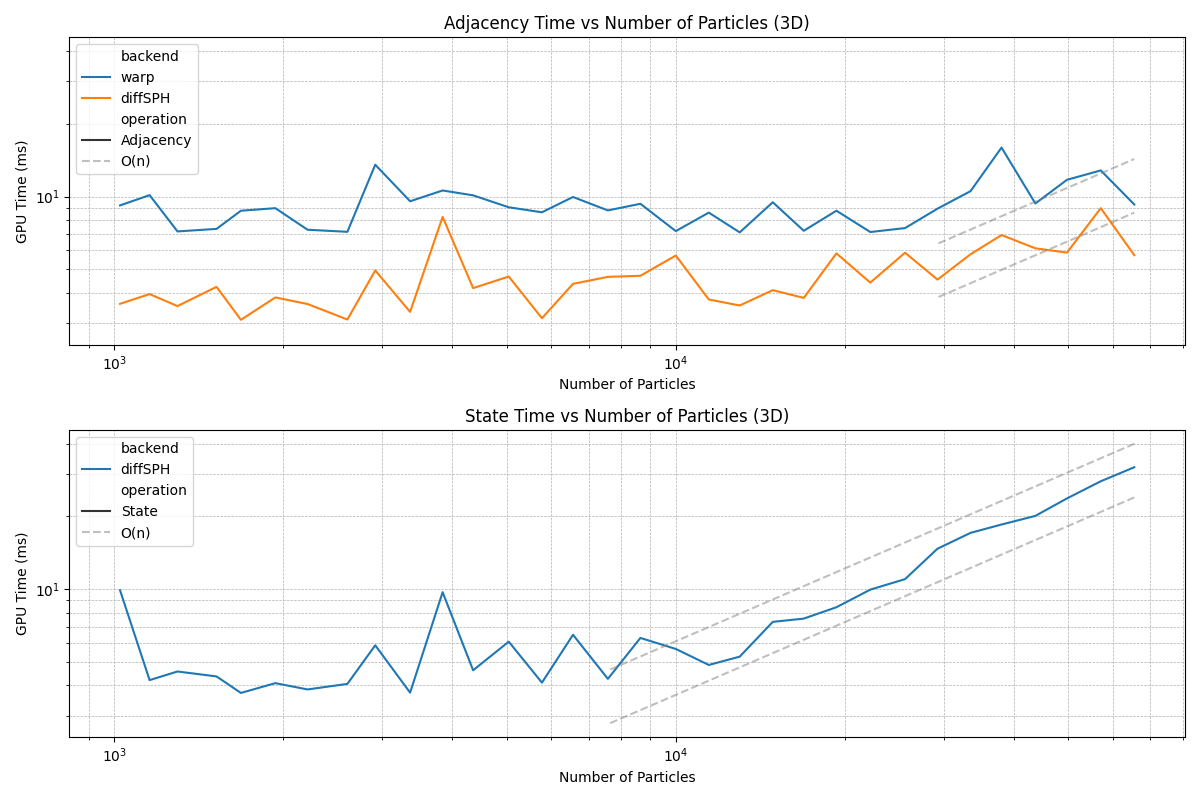

In [16]:
scale_factor = 0.25    

fig, axis = plt.subplots(2, 1, figsize = (12,8), squeeze = False, sharey = True)
import copy

plotData = copy.deepcopy(pdData)

def plotOp(data, operation, ax):
    curData =  data[data['operation'] == operation]

    sns.lineplot(data = curData, x = 'numParticles', y = 'gpuTime', style = 'operation', hue = 'backend', ax = ax, marker = None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Particles')
    ax.set_ylabel('GPU Time (ms)')
    ax.set_title(f'{operation} Time vs Number of Particles (3D)')
    ax.grid(True, which = 'both', linestyle='--', linewidth=0.5)
    add_scaling_line(ax, curData, 'numParticles', 'gpuTime', scale_factor=scale_factor)
    ax.legend()

plotOp(plotData, 'Adjacency', axis[0, 0])
plotOp(plotData, 'State', axis[1, 0])

fig.tight_layout()

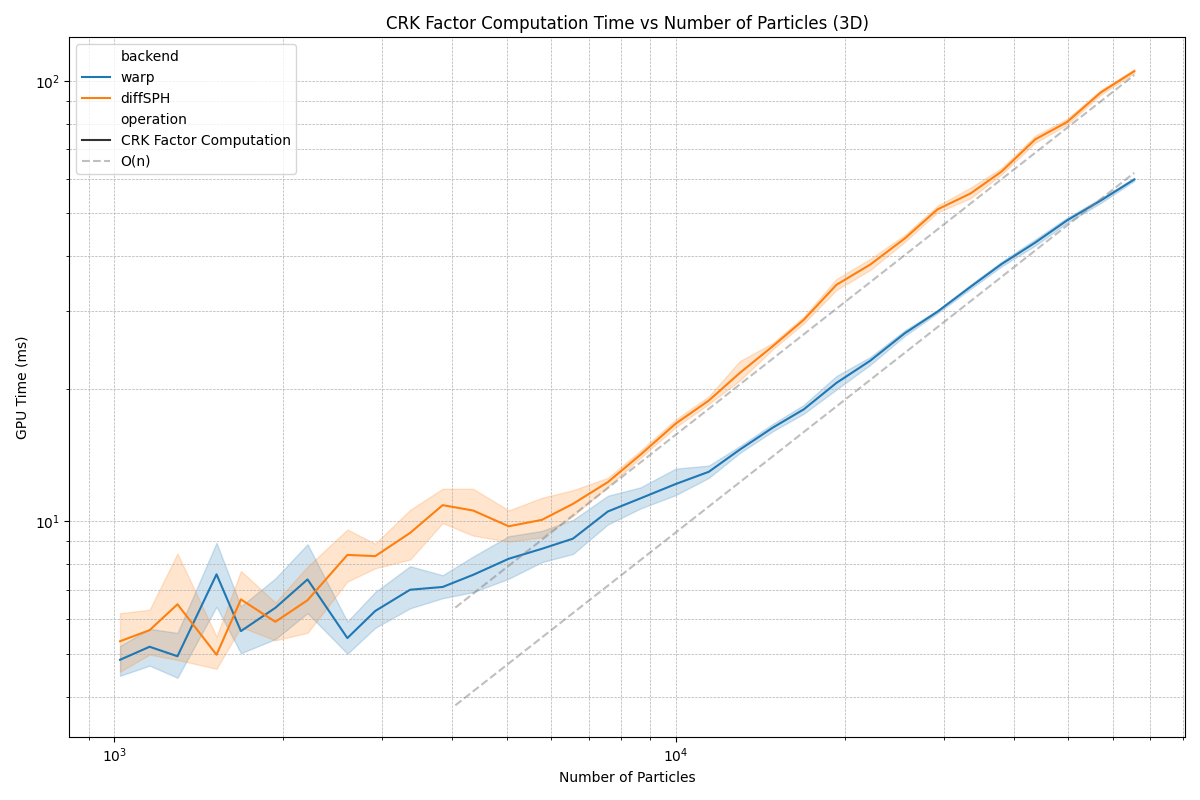

In [18]:
scale_factor = 0.25    

fig, axis = plt.subplots(1, 1, figsize = (12,8), squeeze = False, sharey = True)
import copy

plotData = copy.deepcopy(pdData)

def plotOp(data, operation, ax):
    curData =  data[data['operation'] == operation]

    sns.lineplot(data = curData, x = 'numParticles', y = 'gpuTime', style = 'operation', hue = 'backend', ax = ax, marker = None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Particles')
    ax.set_ylabel('GPU Time (ms)')
    ax.set_title(f'{operation} Time vs Number of Particles (3D)')
    ax.grid(True, which = 'both', linestyle='--', linewidth=0.5)
    add_scaling_line(ax, curData, 'numParticles', 'gpuTime', scale_factor=scale_factor)
    ax.legend()

plotOp(plotData, 'CRK Factor Computation', axis[0, 0])

fig.tight_layout()